## 의사결정 나무 (Decision Tree)



### 알고리즘의 원리

1. **특성 선택**:
- 각 노드에서 데이터를 분할할 특성을 선택한다. 

2. **분할 (Splitting)**:
- 선택된 특성을 기준으로 데이터를 둘 이상의 그룹으로 나눈다. 이 과정은 트리의 각 노드에서 재귀적으로 수행된다.

3. **정지 기준 (Stopping Criteria)**:
- 분할이 멈추는 조건을 설정한다. 보통 최소 샘플 수, 최대 트리 깊이, 최소 불순도 감소량 등의 기준을 사용하여 더 이상 의미 있는 분할이 이루어지지 않을 때 멈춘다.

4. **예측 (Prediction)**:
- 새로운 데이터가 입력되면, 루트 노드에서부터 시작하여 각 노드의 조건을 통해 트리를 따라가며 리프 노드에 도달한다. 리프 노드에 도달하면 해당 노드의 값(분류 문제의 경우 클래스, 회귀 문제의 경우 수치 값)을 예측값으로 반환한다.

### 분할 설명

<img src="https://velog.velcdn.com/images/newnew_daddy/post/f5cbed9c-5e96-49ee-81d0-7ac20a032b59/image.png" width=80%>

1. **노드 (Node)**:
   - **루트 노드 (Root Node)**: 트리의 최상단 노드로, 전체 데이터셋을 포함하며, 첫 번째 분할이 이루어지는 지점을 나타낸다.
   - **내부 노드 (Internal Node)**: 분할된 후의 자식 노드로, 해당 노드의 특성을 기준으로 데이터를 다시 분할한다.
   - **리프 노드 (Leaf Node)**: 더 이상 분할되지 않는 노드로, 최종 예측값(분류 결과 또는 회귀 값)을 나타낸다.

2. **분기 (Branch)**:
   - 각 노드에서 자식 노드로 이동하는 경로를 의미하며, 데이터가 특정 특성과 조건에 따라 분할되는 과정이다.

3. **조건 (Decision)**:
   - 각 노드에서 데이터를 분할할 때 사용되는 기준이다. 주로 이진 분기(binary split)로 나뉘며, 수치형 특성의 경우 특정 값을 기준으로 크거나 작음에 따라, 범주형 특성의 경우 특정 범주에 속하는지에 따라 데이터를 분할한다.

### 불순도
- 결정 트리에서 노드를 분할할 때, 데이터를 나누는 기준이 되는 지표

#### 지니 불순도

- 지니 불순도 : 1 - ([음성 클래스 비율]**2 + [양성 클래스 비율]**2)
- 범위
  - 0 : 노드에 하나의 클래스만 있는 상태(순수 노드)
  - 0.5 : 클래스의 비율이 정확히 반반인, 분할 지표상 최악의 상태
- 지니 분순도가 낮을수록 해당 노드 조건에 대한 클래스 구분이 명확하기 때문에, 지니 불순도가 낮아지는 방향으로 데이터를 분할.

#### 엔트로피
- 데이터의 불순도(혼란도)를 나타내는 척도
- 정도 (0에서 1 사이의 값을 가지며, 0에 가까울수록 더 순수한 상태)
  - 노드의 엔트로피가 낮음 : 해당 노드의 데이터는 하나의 클래스에 가까운 상태(좋음)
  - 노드의 엔트로피가 높음 : 데이터가 여러 클래스에 고르게 분포된 상태(좋지 않음)
$$
Entropy = - \sum \left( p_i \log_2(p_i) \right)
$$

- 각 노드의 엔트로피를 계산하여 그 값을 최소화하는 방향으로 데이터를 분할

In [1]:
import pandas as pd
from utils import evaluate_cls_model, plot_cm

# 와인 품질 이진 분류용 데이터 (alcohol, sugar, pH → class)
wine = pd.read_csv('./dataset/wine.csv')

wine.head(), wine.shape

(   alcohol  sugar    pH  class
 0      9.4    1.9  3.51    0.0
 1      9.8    2.6  3.20    0.0
 2      9.8    2.3  3.26    0.0
 3      9.8    1.9  3.16    0.0
 4      9.4    1.9  3.51    0.0,
 (6497, 4))

In [2]:
X = wine[wine.columns[:-1]].values  # 마지막 열 제외 = 특성
y = wine['class'].values

X.shape, y.shape

((6497, 3), (6497,))

In [4]:
# 70%/30% 분할 (트리는 스케일 불변하지만, 아래에서 비교를 위해 표준화도 수행)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4547, 3), (1950, 3), (4547,), (1950,))

In [5]:
# 결정 트리는 분할 기준이 순서(>, <)라 스케일에 불변. 다만 다른 모델·시각화와 맞출 때 사용
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
train_scaled = ss.fit_transform(X_train)
test_scaled = ss.transform(X_test)

#### DecisionTreeClassifier 메소드의 주요 인자 설명

```python
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion='gini',       # 분할 품질 평가 기준. 'gini' 또는 'entropy'.
    splitter='best',        # 분할 전략. 'best'는 최고의 분할을 선택하고, 'random'은 무작위로 선택.
    max_depth=None,         # 트리의 최대 깊이. None이면 노드가 순수해질 때까지 확장.
    min_samples_split=2,    # 내부 노드를 분할하기 위한 최소 샘플 수.
    min_samples_leaf=1,     # 리프 노드에 필요한 최소 샘플 수.
    max_features=None,      # 분할에 사용할 최대 특성 수. None이면 모든 특성을 사용.
    random_state=None,      # 난수 시드 설정. 결과 재현성을 위해 사용.
    max_leaf_nodes=None,    # 리프 노드의 최대 수. None이면 제한 없음.
    class_weight=None,      # 클래스 가중치. {class_label: weight} 형식의 dict 또는 'balanced'.
)
```

=== DecisionTree (scaled) ===
Train Score: 0.9971
Test  Score: 0.8595

              precision    recall  f1-score   support

         0.0       0.73      0.73      0.73       502
         1.0       0.91      0.90      0.91      1448

    accuracy                           0.86      1950
   macro avg       0.82      0.82      0.82      1950
weighted avg       0.86      0.86      0.86      1950



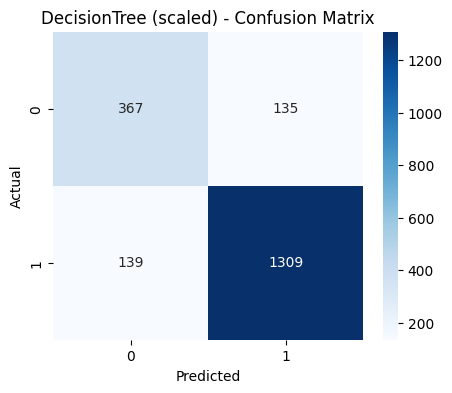

In [6]:
from sklearn.tree import DecisionTreeClassifier

"""
https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
"""

# 기본값: 깊이 제한 없음 → 학습 데이터에 과적합되기 쉬움
dt = DecisionTreeClassifier(random_state=42)
dt.fit(train_scaled, y_train)

y_pred = evaluate_cls_model(dt, train_scaled, test_scaled, y_train, y_test, "DecisionTree (scaled)")
plot_cm(y_test, y_pred, "DecisionTree (scaled)")


=== DecisionTree (raw) ===
Train Score: 0.9971
Test  Score: 0.8600

              precision    recall  f1-score   support

         0.0       0.73      0.73      0.73       502
         1.0       0.91      0.90      0.91      1448

    accuracy                           0.86      1950
   macro avg       0.82      0.82      0.82      1950
weighted avg       0.86      0.86      0.86      1950



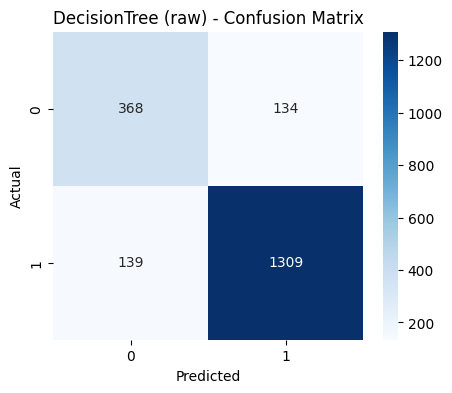

In [7]:
# 스케일링 없는 원특성으로 동일 설정 학습 (점수는 스케일과 무관하게 동일 경향)
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred = evaluate_cls_model(dt, X_train, X_test, y_train, y_test, "DecisionTree (raw)")
plot_cm(y_test, y_pred, "DecisionTree (raw)")


In [8]:
# feature_importances_: 분할에 기여한 정도(합은 1)
pd.concat(
    [pd.DataFrame(wine.columns[:-1]), pd.DataFrame(dt.feature_importances_)],
    axis=1,
)

,0,0
0,alcohol,0.228902
1,sugar,0.517006
2,pH,0.254093


### 1. **`plot_tree`**: 결정 트리 시각화

- `plot_tree` 메소드는 학습된 결정 트리 모델을 **시각화**하는 기능을 제공

#### **주요 기능**:
- **결정 트리의 구조를 그래픽으로 표현**: 각 노드가 어떤 특성을 기준으로 데이터를 분할했는지, 해당 노드에 포함된 샘플 수, 지니 불순도나 엔트로피 값, 각 클래스의 분포 등을 시각적으로 보여줍니다.
- **특성 중요도 이해**: 시각적으로 트리의 가지가 어떻게 형성되었는지를 볼 수 있기 때문에, 트리의 각 노드가 어떤 특성을 기준으로 데이터를 분할했는지 명확하게 확인할 수 있습니다.

#### **주요 매개변수**:
- `decision_tree`: 시각화할 학습된 결정 트리 모델 (`DecisionTreeClassifier`나 `DecisionTreeRegressor`).
- `feature_names`: 트리에서 사용한 각 특성의 이름을 표시할 수 있습니다.
- `class_names`: 분류 문제일 때, 각 클래스의 이름을 표시할 수 있습니다.
- `filled`: `True`로 설정하면 노드의 색상을 클래스나 값에 따라 채웁니다. 트리의 각 노드를 시각적으로 구분하는 데 유용합니다.
- `rounded`: `True`로 설정하면 노드의 모서리가 둥글게 표시됩니다.


### 2. **`export_text`**: 결정 트리의 텍스트 표현

- `export_text` 메소드는 학습된 결정 트리 모델을 **텍스트 형식**으로 출력

#### **주요 기능**:
- **결정 트리의 노드 분할 규칙을 텍스트로 표현**: 각 노드에서 어떤 특성을 기준으로 데이터를 분할했는지, 그 기준 값과 해당 노드에 속한 샘플의 개수 등을 텍스트 형식으로 제공합니다.
- **간결한 트리 구조 설명**: 트리의 깊이, 노드의 조건 등을 텍스트로 빠르게 이해할 수 있습니다.

#### **주요 매개변수**:
- `decision_tree`: 텍스트로 표현할 학습된 결정 트리 모델.
- `feature_names`: 분할에 사용된 각 특성의 이름을 출력에 포함할 수 있습니다.
- `max_depth`: 출력할 트리의 최대 깊이를 설정할 수 있습니다. 트리가 너무 깊으면 가독성이 떨어지기 때문에 깊이를 제한할 수 있습니다.

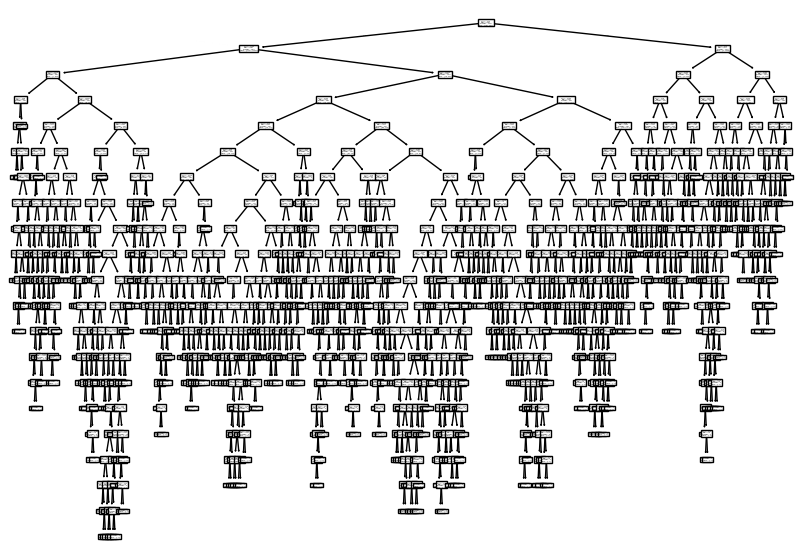

In [9]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree, export_text

plt.figure(figsize=(10, 7))
plot_tree(dt)  # 기본: 전체 트리(깊으면 매우 복잡)
plt.show()

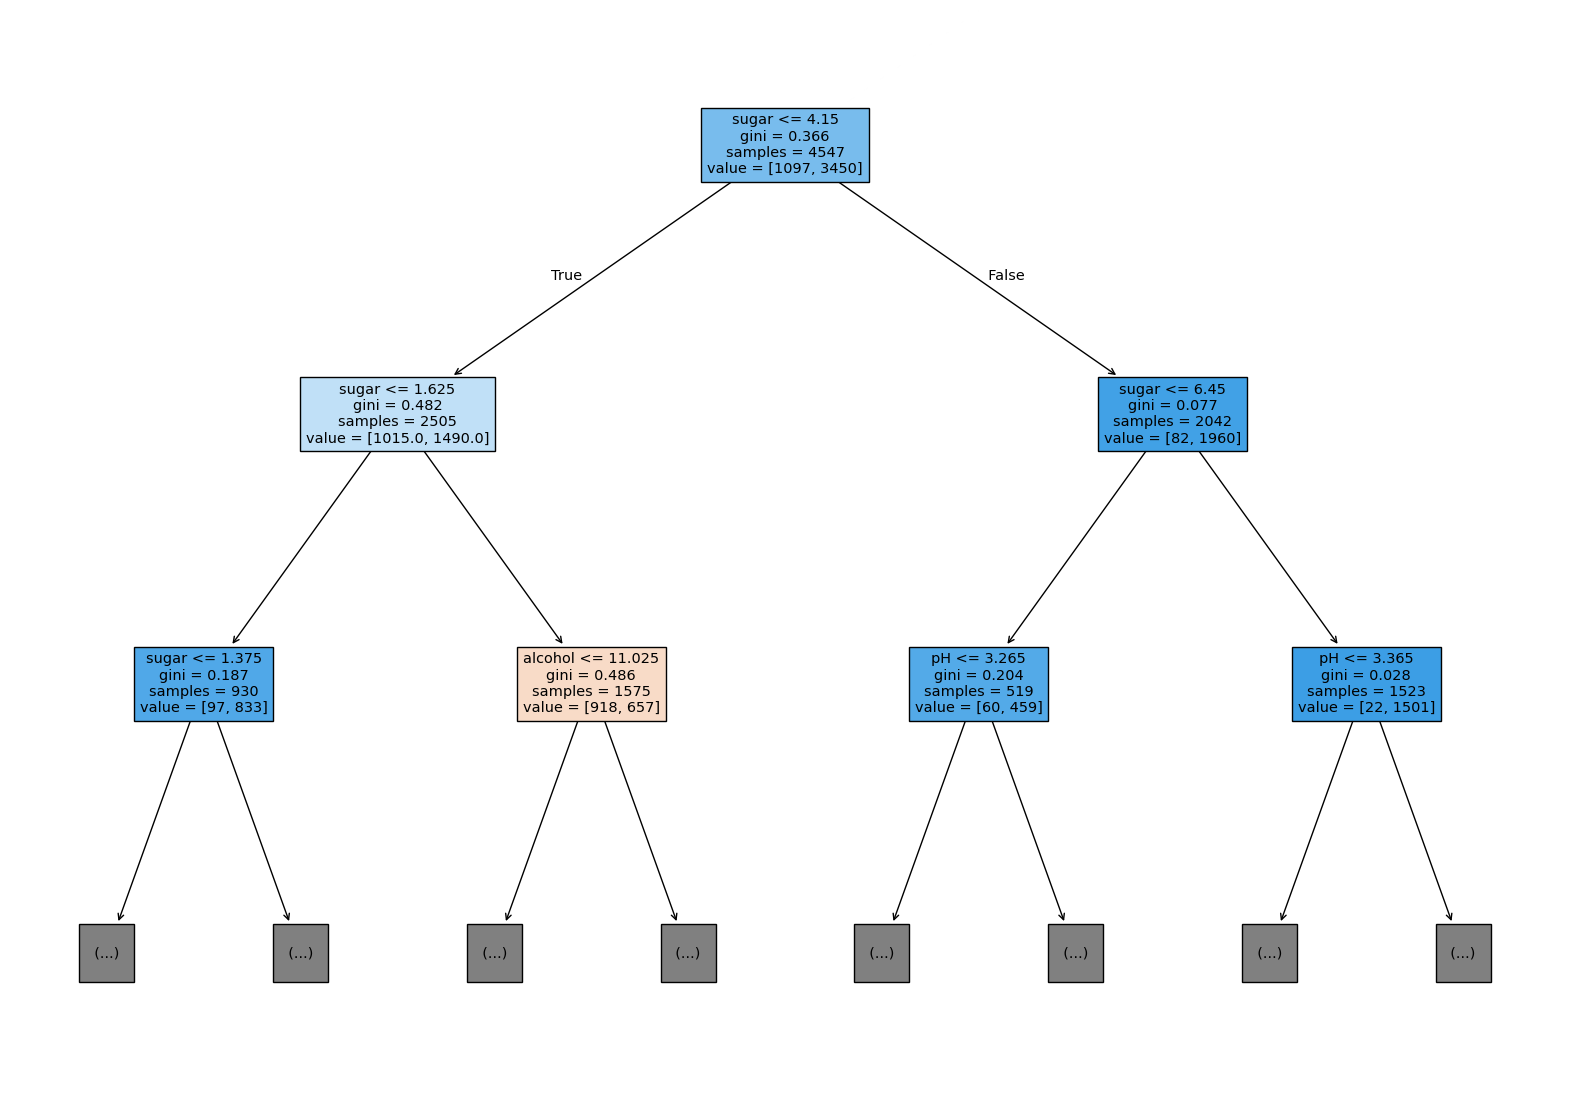

In [10]:
plt.figure(figsize=(20, 14))
# max_depth=2: 상위 두 층만 시각화, filled=True: 클래스 비율에 따라 색 채움
plot_tree(dt, max_depth=2, filled=True, feature_names=['alcohol', 'sugar', 'pH'])
plt.show()

In [11]:
# 텍스트로 트리 규칙 덤프(앞부분만 출력)
tree_text = export_text(dt, max_depth=2, feature_names=['alcohol', 'sugar', 'pH'])
print(tree_text[:5000])

|--- sugar <= 4.15
|   |--- sugar <= 1.62
|   |   |--- sugar <= 1.38
|   |   |   |--- truncated branch of depth 10
|   |   |--- sugar >  1.38
|   |   |   |--- truncated branch of depth 18
|   |--- sugar >  1.62
|   |   |--- alcohol <= 11.03
|   |   |   |--- truncated branch of depth 17
|   |   |--- alcohol >  11.03
|   |   |   |--- truncated branch of depth 16
|--- sugar >  4.15
|   |--- sugar <= 6.45
|   |   |--- pH <= 3.26
|   |   |   |--- truncated branch of depth 10
|   |   |--- pH >  3.26
|   |   |   |--- truncated branch of depth 15
|   |--- sugar >  6.45
|   |   |--- pH <= 3.36
|   |   |   |--- truncated branch of depth 10
|   |   |--- pH >  3.36
|   |   |   |--- truncated branch of depth 7



=== DecisionTree depth=3 (scaled) ===
Train Score: 0.8494
Test  Score: 0.8400

              precision    recall  f1-score   support

         0.0       0.72      0.62      0.66       502
         1.0       0.87      0.92      0.89      1448

    accuracy                           0.84      1950
   macro avg       0.80      0.77      0.78      1950
weighted avg       0.83      0.84      0.84      1950



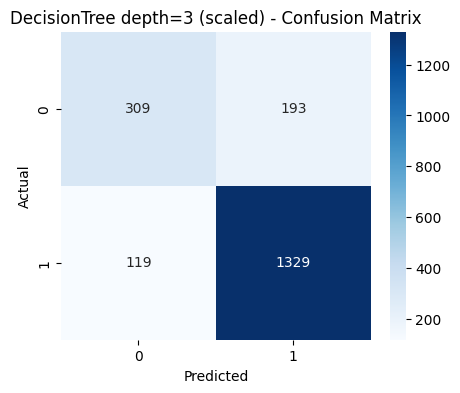

In [12]:
# max_depth=3: 과적합 완화, 해석도 쉬워짐
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(train_scaled, y_train)

y_pred = evaluate_cls_model(dt, train_scaled, test_scaled, y_train, y_test, "DecisionTree depth=3 (scaled)")
plot_cm(y_test, y_pred, "DecisionTree depth=3 (scaled)")


=== DecisionTree depth=3 (raw) ===
Train Score: 0.8494
Test  Score: 0.8400

              precision    recall  f1-score   support

         0.0       0.72      0.62      0.66       502
         1.0       0.87      0.92      0.89      1448

    accuracy                           0.84      1950
   macro avg       0.80      0.77      0.78      1950
weighted avg       0.83      0.84      0.84      1950



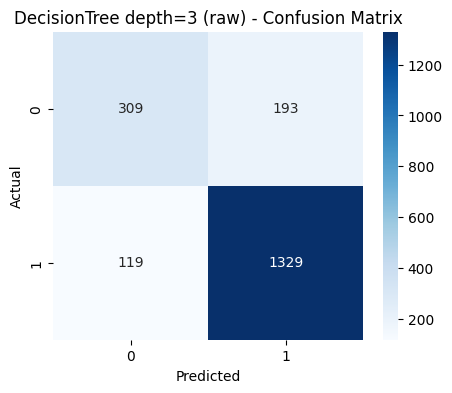

In [13]:
# max_depth=3, 원특성 — 스케일링 없이 동일 구조 검증
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

y_pred = evaluate_cls_model(dt, X_train, X_test, y_train, y_test, "DecisionTree depth=3 (raw)")
plot_cm(y_test, y_pred, "DecisionTree depth=3 (raw)")


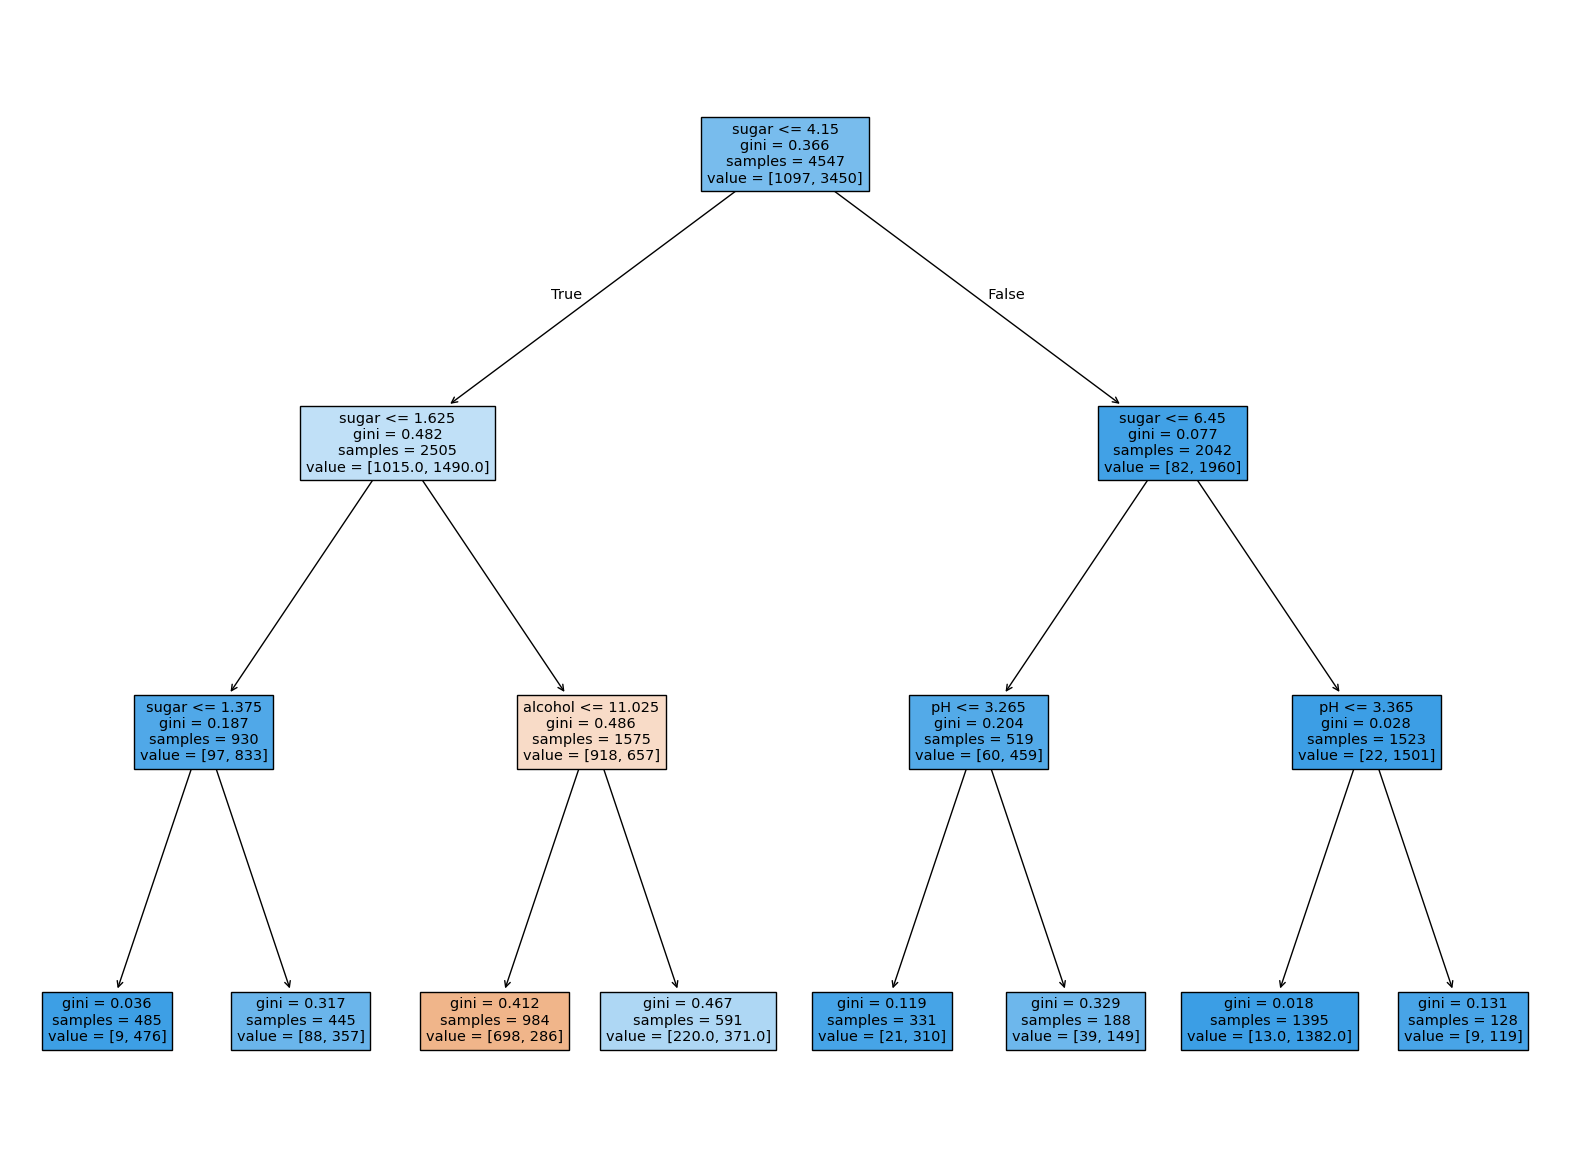

In [14]:
plt.figure(figsize=(20, 15))
plot_tree(dt, filled=True, feature_names=['alcohol', 'sugar', 'pH'])  # max_depth=3로 제한된 트리
plt.show()